# 📱 手机传感器技术 —— Python 演示程序集

> 本 Notebook 汇总了 [手机传感器技术](https://zebedee2021.github.io/Mobile-Sensor-2026/) 课程网站中的所有 Python 代码示例，可在 Google Colab 中直接运行。

**内容组织:**
1. 环境准备
2. 传感器基础算法 (加速度计、陀螺仪、磁力计、气压计)
3. 数据采集实验 (计步器、指南针、楼层检测、手势识别)
4. SensorLog 数据分析
5. 数据上云服务端 (参考代码)

---
## 1. 环境准备

运行下方单元格安装所需依赖。Colab 已预装 numpy、pandas、matplotlib、scipy、scikit-learn。

> **中文显示**: Colab 默认无中文字体，下方代码会自动安装 Noto Sans CJK 字体。首次运行需要几秒钟。

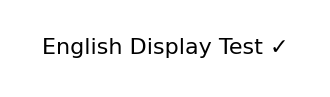

Environment setup complete!


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# Environment Setup
# (Removed Chinese font setup as requested to switch to English)
# ============================================================

# No special font setup needed for English.
# Matplotlib uses DejaVu Sans by default, which supports English.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Explicitly set to a common English font
plt.rcParams['axes.unicode_minus'] = True # Revert to default for minus sign

# Validate English display
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, 'English Display Test ✓', ha='center', va='center', fontsize=16)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
plt.show()

print('Environment setup complete!')

---
## 2. 传感器基础算法

本节演示各类传感器的基础算法，使用合成数据即可运行。

### 2.1 加速度计: 屏幕方向检测

通过检测重力加速度在 X、Y 轴上的分量判断手机朝向。

In [35]:
import math

def detect_orientation(ax, ay, az):
    """Detects screen orientation based on accelerometer data"""
    angle = math.atan2(ay, ax) * 180 / math.pi

    if 45 < angle < 135:
        return "Portrait"
    elif -135 < angle < -45:
        return "Portrait Inverted"
    elif -45 < angle < 45:
        return "Landscape Right"
    else:
        return "Landscape Left"

# Test: Simulate accelerometer values for different orientations
test_cases = [
    (0.0, 9.8, 0.0,   "Phone upright"),
    (0.0, -9.8, 0.0,  "Phone inverted"),
    (9.8, 0.0, 0.0,   "Phone landscape right"),
    (-9.8, 0.0, 0.0,  "Phone landscape left"),
    (0.0, 0.0, -9.8,  "Phone flat, screen up"),
]

print("Accelerometer Screen Orientation Detection Demo")
print("=" * 50)
for ax, ay, az, desc in test_cases:
    result = detect_orientation(ax, ay, az)
    print(f"{desc:25s} | ax={ax:6.1f}, ay={ay:6.1f} | -> {result}")

Accelerometer Screen Orientation Detection Demo
Phone upright             | ax=   0.0, ay=   9.8 | -> Portrait
Phone inverted            | ax=   0.0, ay=  -9.8 | -> Portrait Inverted
Phone landscape right     | ax=   9.8, ay=   0.0 | -> Landscape Right
Phone landscape left      | ax=  -9.8, ay=   0.0 | -> Landscape Left
Phone flat, screen up     | ax=   0.0, ay=   0.0 | -> Landscape Right


### 2.2 加速度计: 简易计步器

利用加速度合成量的周期性波峰检测步态。

Simulation duration: 50s, Step frequency: 2.0Hz
Theoretical steps: 100
Detected steps: 99


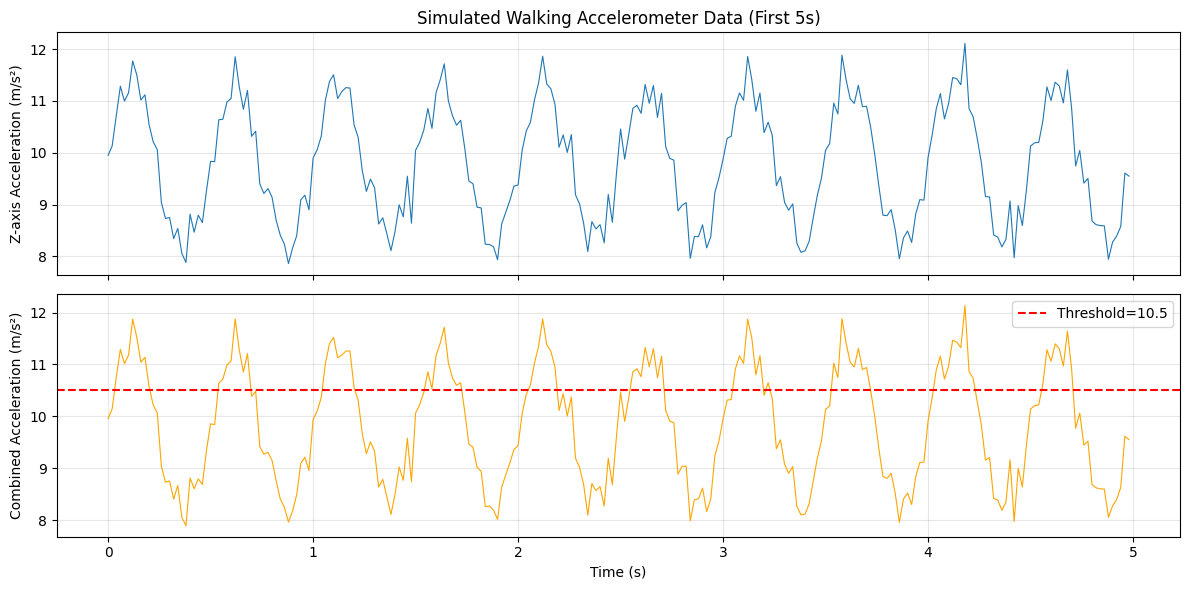

In [36]:
import math
import numpy as np
import matplotlib.pyplot as plt

def compute_magnitude(ax, ay, az):
    """Computes accelerometer magnitude"""
    return math.sqrt(ax**2 + ay**2 + az**2)

def simple_step_counter(data, threshold=10.5, min_interval=0.3):
    """
    Simple peak detection step counter
    data: [(timestamp, ax, ay, az), ...]
    """
    steps = 0
    last_step_time = 0

    for t, ax, ay, az in data:
        mag = compute_magnitude(ax, ay, az)
        if mag > threshold and (t - last_step_time) > min_interval:
            steps += 1
            last_step_time = t

    return steps

# Generate simulated walking data (100 steps, ~2Hz cadence)
np.random.seed(42)
fs = 50  # Sampling rate 50Hz
duration = 50  # 50 seconds
t = np.arange(0, duration, 1/fs)

# Gravity baseline (9.8 m/s²) + walking waveform (~2Hz sine wave) + noise
step_freq = 2.0  # Hz
az_sim = 9.8 + 1.5 * np.sin(2 * np.pi * step_freq * t) + np.random.normal(0, 0.3, len(t))
ax_sim = np.random.normal(0, 0.5, len(t))
ay_sim = np.random.normal(0, 0.5, len(t))
mag = np.sqrt(ax_sim**2 + ay_sim**2 + az_sim**2)

# Step counting
data = list(zip(t, ax_sim, ay_sim, az_sim))
steps = simple_step_counter(data, threshold=10.5, min_interval=0.3)
print(f"Simulation duration: {duration}s, Step frequency: {step_freq}Hz")
print(f"Theoretical steps: {int(duration * step_freq)}")
print(f"Detected steps: {steps}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t[:250], az_sim[:250], linewidth=0.8)
axes[0].set_ylabel('Z-axis Acceleration (m/s²)')
axes[0].set_title('Simulated Walking Accelerometer Data (First 5s)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:250], mag[:250], linewidth=0.8, color='orange')
axes[1].axhline(y=10.5, color='r', linestyle='--', label='Threshold=10.5')
axes[1].set_ylabel('Combined Acceleration (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 陀螺仪: 电子图像稳定 (EIS)

根据陀螺仪角速度数据计算补偿旋转，实现电子防抖。

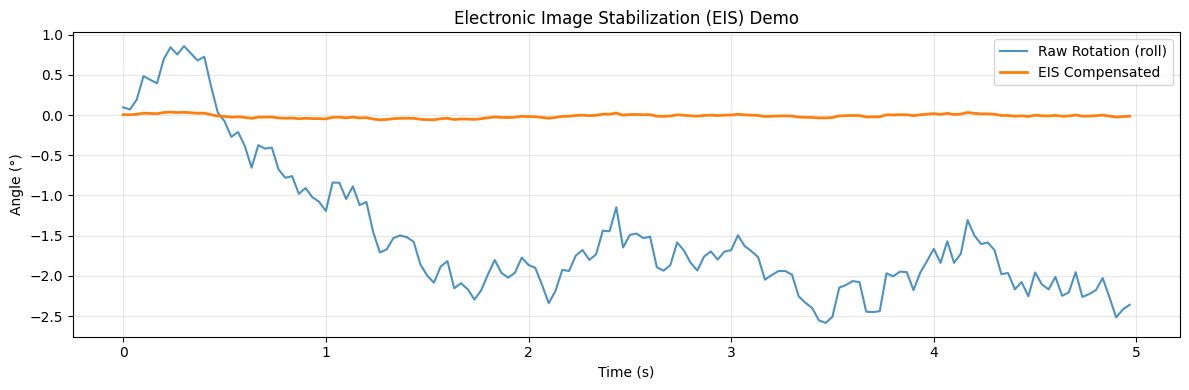

In [37]:
import math
import numpy as np
import matplotlib.pyplot as plt

def eis_compensation(frame_rotation, gyro_data, dt):
    """
    Electronic Image Stabilization: Calculates compensation rotation based on gyroscope data
    gyro_data: (gx, gy, gz) rad/s
    dt: Sampling interval (s)
    """
    # Angular increment = Angular velocity × Time
    d_roll  = gyro_data[0] * dt
    d_pitch = gyro_data[1] * dt
    d_yaw   = gyro_data[2] * dt

    # Simplified low-pass filter for smoothing
    alpha = 0.95
    smoothed_roll  = alpha * frame_rotation[0] + (1 - alpha) * d_roll
    smoothed_pitch = alpha * frame_rotation[1] + (1 - alpha) * d_pitch

    return (smoothed_roll, smoothed_pitch, d_yaw)

# Demo: Simulate camera shake during handheld shooting
np.random.seed(42)
dt = 1 / 30  # 30fps
n_frames = 150  # 5 seconds

# Simulate gyroscope shake data (rad/s)
gyro_roll  = np.random.normal(0, 0.1, n_frames)
gyro_pitch = np.random.normal(0, 0.08, n_frames)
gyro_yaw   = np.random.normal(0, 0.05, n_frames)

# Accumulate raw rotation and compensated rotation
raw_angles = []
comp_angles = []
raw_rot = (0, 0, 0)
comp_rot = (0, 0, 0)

for i in range(n_frames):
    gyro = (gyro_roll[i], gyro_pitch[i], gyro_yaw[i])
    raw_rot = (raw_rot[0] + gyro[0]*dt, raw_rot[1] + gyro[1]*dt, raw_rot[2] + gyro[2]*dt)
    comp_rot = eis_compensation(comp_rot, gyro, dt)
    raw_angles.append(math.degrees(raw_rot[0]))
    comp_angles.append(math.degrees(comp_rot[0]))

t = np.arange(n_frames) * dt
plt.figure(figsize=(12, 4))
plt.plot(t, raw_angles, label='Raw Rotation (roll)', alpha=0.8)
plt.plot(t, comp_angles, label='EIS Compensated', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Angle (°)')
plt.title('Electronic Image Stabilization (EIS) Demo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 陀螺仪: 互补滤波器

融合加速度计 (低频可信) 和陀螺仪 (高频可信)，计算稳定的姿态角。

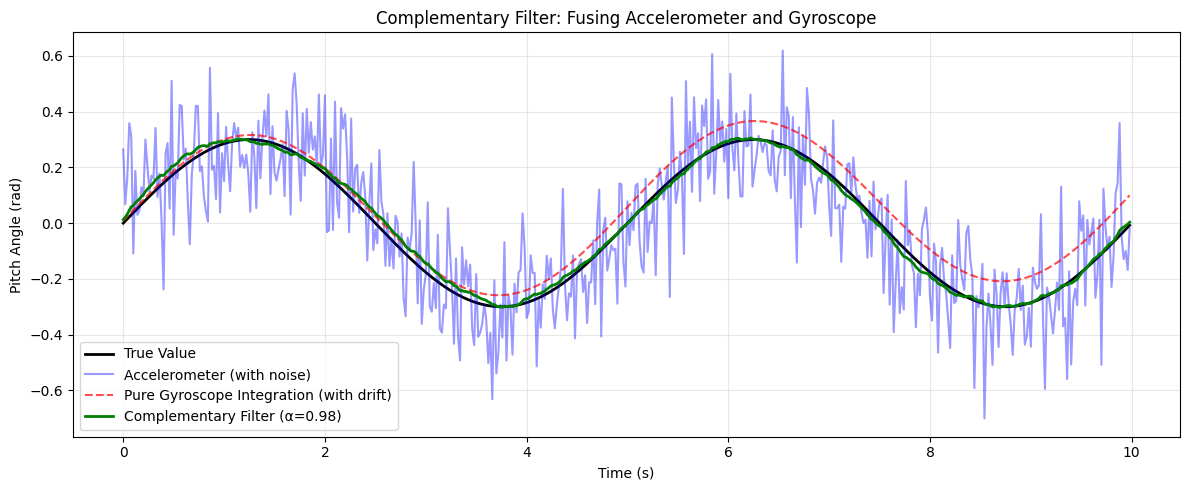

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt

class ComplementaryFilter:
    """Complementary Filter: Fuses accelerometer (reliable at low frequencies) and gyroscope (reliable at high frequencies)"""

    def __init__(self, alpha=0.98):
        self.alpha = alpha
        self.pitch = 0.0
        self.roll = 0.0

    def update(self, ax, ay, az, gx, gy, gz, dt):
        # Accelerometer estimated angles
        accel_pitch = math.atan2(ax, math.sqrt(ay**2 + az**2))
        accel_roll  = math.atan2(ay, math.sqrt(ax**2 + az**2))

        # Complementary filter
        self.pitch = self.alpha * (self.pitch + gx * dt) + (1 - self.alpha) * accel_pitch
        self.roll  = self.alpha * (self.roll  + gy * dt) + (1 - self.alpha) * accel_roll

        return self.pitch, self.roll

# Demo: Simulate gyroscope with drift and accelerometer with noise
np.random.seed(0)
dt = 0.02  # 50Hz
n = 500    # 10 seconds
t = np.arange(n) * dt

# True pitch angle: slow oscillation
true_pitch = 0.3 * np.sin(2 * np.pi * 0.2 * t)

# Accelerometer: noisy but no drift
accel_pitch = true_pitch + np.random.normal(0, 0.15, n)

# Gyroscope: no noise but with drift
gyro_rate = np.gradient(true_pitch, dt) + 0.01  # Add constant offset

# Pure gyroscope integration (with drift)
gyro_only = np.cumsum(gyro_rate * dt)

# Complementary filter
cf = ComplementaryFilter(alpha=0.98)
cf_pitch = []
for i in range(n):
    ax_i = math.sin(accel_pitch[i]) * 9.8
    az_i = math.cos(accel_pitch[i]) * 9.8
    p, _ = cf.update(ax_i, 0, az_i, gyro_rate[i], 0, 0, dt)
    cf_pitch.append(p)

plt.figure(figsize=(12, 5))
plt.plot(t, true_pitch, 'k-', label='True Value', linewidth=2)
plt.plot(t, accel_pitch, 'b-', label='Accelerometer (with noise)', alpha=0.4)
plt.plot(t, gyro_only, 'r--', label='Pure Gyroscope Integration (with drift)', alpha=0.7)
plt.plot(t, cf_pitch, 'g-', label='Complementary Filter (α=0.98)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Pitch Angle (rad)')
plt.title('Complementary Filter: Fusing Accelerometer and Gyroscope')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 磁力计: 椭球拟合标定

手机内部永磁材料会产生硬铁干扰，通过"8"字标定消除偏置。

Hard-iron offset: [14.8, -10.0, 5.6] μT
Soft-iron scale:  [0.881, 1.125, 1.024]
True offset:      [15, -10, 5] μT


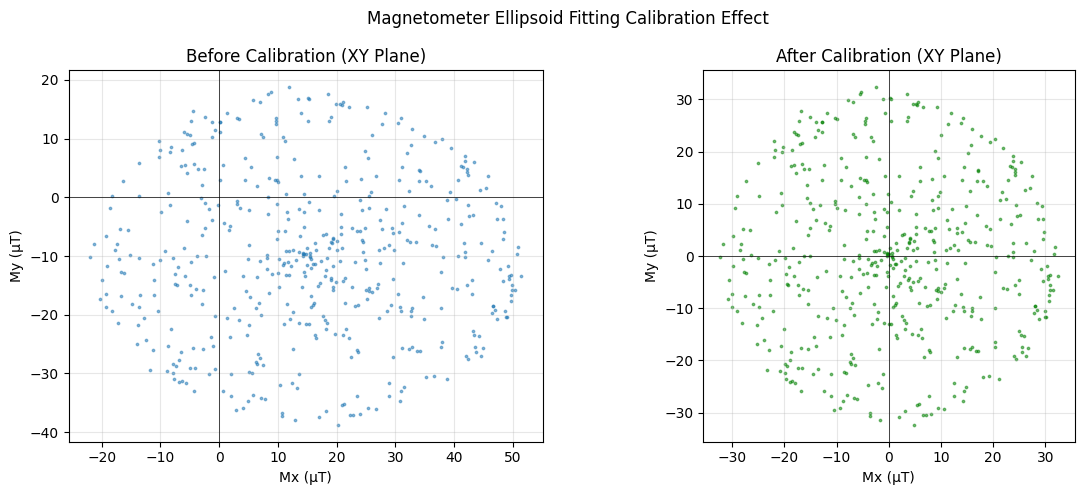

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def calibrate_magnetometer(raw_data):
    """
    Ellipsoid fitting calibration (simplified)
    raw_data: Nx3 array [(mx, my, mz), ...]
    Returns: offset (hard-iron bias), scale (soft-iron correction)
    """
    # Estimate offset by finding the midpoint of max and min values for each axis
    offset = np.mean([np.max(raw_data, axis=0),
                      np.min(raw_data, axis=0)], axis=0)

    # Estimate scale by taking the ratio of average range to individual axis ranges
    ranges = np.max(raw_data, axis=0) - np.min(raw_data, axis=0)
    avg_range = np.mean(ranges)
    scale = avg_range / ranges

    return offset, scale

def apply_calibration(raw, offset, scale):
    """Applies calibration parameters"""
    return (raw - offset) * scale

# Simulate 'figure-eight' calibration data: sphere + bias + ellipticity
np.random.seed(42)
n_points = 500
theta = np.random.uniform(0, 2 * np.pi, n_points)
phi = np.random.uniform(-np.pi/2, np.pi/2, n_points)

# True sphere (30 μT radius) + hard-iron bias + soft-iron stretching
hard_iron = np.array([15, -10, 5])    # Hard-iron bias
soft_iron = np.array([1.2, 0.9, 1.0]) # Soft-iron stretching
r = 30  # Earth's magnetic field strength (μT)

raw_data = np.column_stack([
    r * np.cos(phi) * np.cos(theta) * soft_iron[0] + hard_iron[0],
    r * np.cos(phi) * np.sin(theta) * soft_iron[1] + hard_iron[1],
    r * np.sin(phi) * soft_iron[2] + hard_iron[2]
]) + np.random.normal(0, 1, (n_points, 3))  # Add noise

# Calibrate
offset, scale = calibrate_magnetometer(raw_data)
calibrated = apply_calibration(raw_data, offset, scale)

print(f"Hard-iron offset: [{offset[0]:.1f}, {offset[1]:.1f}, {offset[2]:.1f}] μT")
print(f"Soft-iron scale:  [{scale[0]:.3f}, {scale[1]:.3f}, {scale[2]:.3f}]")
print(f"True offset:      [{hard_iron[0]}, {hard_iron[1]}, {hard_iron[2]}] μT")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(raw_data[:, 0], raw_data[:, 1], s=3, alpha=0.5)
axes[0].set_title('Before Calibration (XY Plane)')
axes[0].set_xlabel('Mx (μT)')
axes[0].set_ylabel('My (μT)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].scatter(calibrated[:, 0], calibrated[:, 1], s=3, alpha=0.5, color='green')
axes[1].set_title('After Calibration (XY Plane)')
axes[1].set_xlabel('Mx (μT)')
axes[1].set_ylabel('My (μT)')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

plt.suptitle('Magnetometer Ellipsoid Fitting Calibration Effect')
plt.tight_layout()
plt.show()

### 2.6 磁力计: 电子指南针 (倾斜补偿)

利用加速度计数据进行倾斜补偿，计算磁航向角。

Electronic Compass Demo
Attitude: Level        | Heading: -0.0° (should be close to 0°/360°)
Attitude: pitch=17°    | Heading: -0.0° (should be close to 0°/360°)
Attitude: roll=17°     | Heading: 336.1° (should be close to 0°/360°)


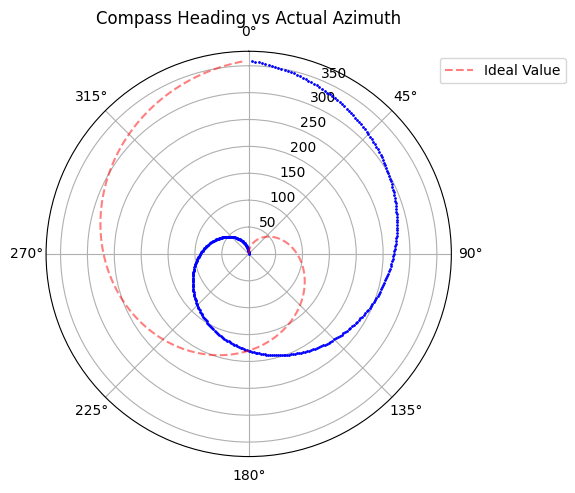

In [40]:
import math
import numpy as np
import matplotlib.pyplot as plt

def compass_heading(mx, my, mz, pitch, roll):
    """
    Calculates magnetic heading (with tilt compensation)
    mx, my, mz: Magnetometer readings (μT)
    pitch, roll: Tilt angles from accelerometer (rad)
    """
    # Tilt compensation
    mx_comp = (mx * math.cos(pitch)
               + mz * math.sin(pitch))
    my_comp = (mx * math.sin(roll) * math.sin(pitch)
               + my * math.cos(roll)
               - mz * math.sin(roll) * math.cos(pitch))

    # Calculate heading angle
    heading = math.atan2(-my_comp, mx_comp)
    heading_deg = math.degrees(heading)

    if heading_deg < 0:
        heading_deg += 360

    return heading_deg

# Demo: Compass rotating 360 degrees
n = 360
angles = np.linspace(0, 360, n, endpoint=False)
headings = []

Bh = 30.0  # Horizontal magnetic field component (μT), e.g., Beijing region
Bv = -45.0 # Vertical magnetic field component (downwards in Northern Hemisphere)

for a in angles:
    rad = math.radians(a)
    mx = Bh * math.cos(rad)
    my = Bh * math.sin(rad)
    mz = Bv
    h = compass_heading(mx, my, mz, pitch=0, roll=0)
    headings.append(h)

# Test with tilt
print("Electronic Compass Demo")
print("=" * 50)
test_tilts = [(0, 0, "Level"), (0.3, 0, "pitch=17°"), (0, 0.3, "roll=17°")]
for pitch, roll, desc in test_tilts:
    h = compass_heading(Bh, 0, Bv, pitch, roll)
    print(f"Attitude: {desc:12s} | Heading: {h:.1f}° (should be close to 0°/360°)")

# Plot polar graph
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.plot(np.radians(angles), headings, 'b.', markersize=2)
ax.plot(np.radians(angles), angles, 'r--', alpha=0.5, label='Ideal Value')
ax.set_title('Compass Heading vs Actual Azimuth', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

### 2.7 气压计: 气压转海拔 & 楼层检测

利用气压高度公式将气压转化为海拔，并检测楼层变化。

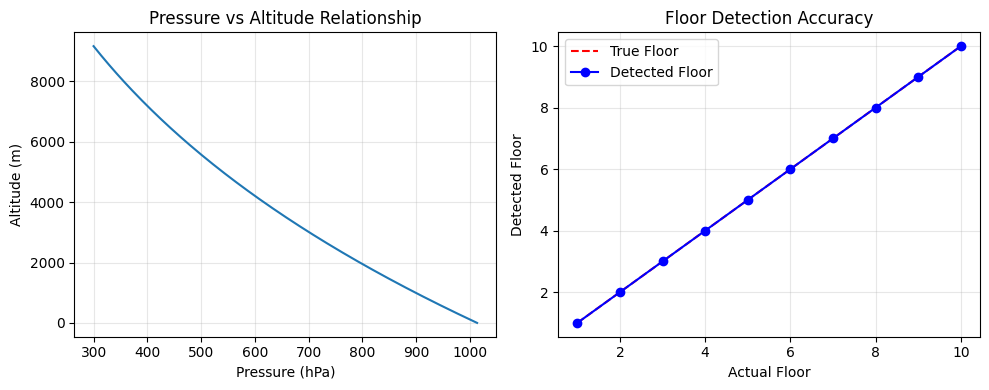


Floor Detection Detailed Data:
Floor Pressure(hPa)  Relative Altitude(m)  Detected Floor 
1     1013.25        0.00                  1              
2     1012.89        3.00                  2              
3     1012.53        6.00                  3              
4     1012.17        9.00                  4              
5     1011.81        12.00                 5              
6     1011.45        15.00                 6              
7     1011.09        18.00                 7              
8     1010.73        21.00                 8              
9     1010.37        24.01                 9              
10    1010.01        27.01                 10             


In [41]:
import numpy as np
import matplotlib.pyplot as plt

def pressure_to_altitude(pressure, sea_level_pressure=1013.25):
    """Converts pressure to altitude (m)"""
    return 44330.0 * (1.0 - (pressure / sea_level_pressure) ** 0.1903)

def detect_floor_change(p1, p2, floor_height=3.0):
    """Detects floor changes"""
    h1 = pressure_to_altitude(p1)
    h2 = pressure_to_altitude(p2)
    delta_floors = (h2 - h1) / floor_height
    return round(delta_floors)

# Demo 1: Pressure vs Altitude relationship
pressures = np.linspace(300, 1013.25, 200)
altitudes = [pressure_to_altitude(p) for p in pressures]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(pressures, altitudes)
plt.xlabel('Pressure (hPa)')
plt.ylabel('Altitude (m)')
plt.title('Pressure vs Altitude Relationship')
plt.grid(True, alpha=0.3)

# Demo 2: Simulate going upstairs
base_pressure = 1013.25
floors_data = []
for floor in range(1, 11):
    p = base_pressure - (floor - 1) * 0.36
    h = pressure_to_altitude(p) - pressure_to_altitude(base_pressure)
    detected = detect_floor_change(base_pressure, p)
    floors_data.append((floor, p, h, detected + 1))

plt.subplot(1, 2, 2)
real_floors = [f[0] for f in floors_data]
detected_floors = [f[3] for f in floors_data]
plt.plot(real_floors, real_floors, 'r--', label='True Floor')
plt.plot(real_floors, detected_floors, 'bo-', label='Detected Floor')
plt.xlabel('Actual Floor')
plt.ylabel('Detected Floor')
plt.title('Floor Detection Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed data
print("\nFloor Detection Detailed Data:")
print(f"{'Floor':<6s}{'Pressure(hPa)':<15s}{'Relative Altitude(m)':<22s}{'Detected Floor':<15s}")
for floor, p, h, det in floors_data:
    print(f"{floor:<6d}{p:<15.2f}{h:<22.2f}{det:<15d}")

---
## 3. 数据采集实验

本节演示完整的数据分析流程，使用合成数据模拟实际采集场景。

> 💡 实际使用时，将合成数据替换为 SensorLog / Sensor Logger 导出的 CSV 文件即可。

### 3.1 实验一: 计步器 (带通滤波 + 峰值检测)

使用 scipy 的带通滤波和峰值检测实现更精确的计步算法。

Detected steps: 100
Theoretical steps: 100
Error: 0 steps


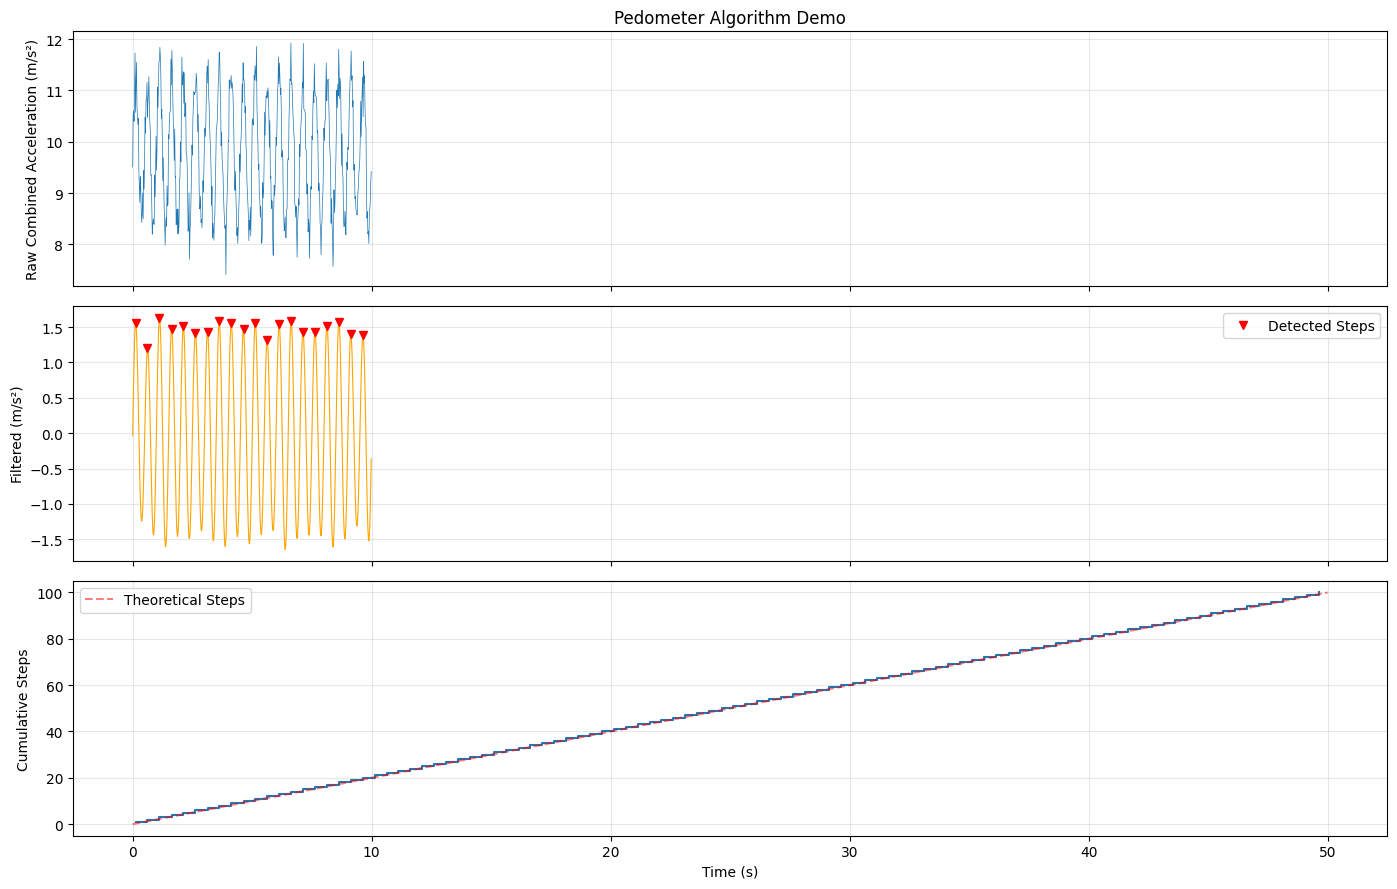

In [42]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt
import matplotlib.pyplot as plt

# Generate simulated data (instead of actual CSV)
np.random.seed(123)
fs = 50  # Sampling rate 50Hz
duration = 50  # 50 seconds
n_samples = fs * duration
t = np.arange(n_samples) / fs

# Simulate 100 steps of accelerometer data
step_freq = 2.0  # 2Hz cadence
noise = np.random.normal(0, 0.3, n_samples)
df = pd.DataFrame({
    'accelerometerAccelerationX': np.random.normal(0, 0.5, n_samples),
    'accelerometerAccelerationY': np.random.normal(0, 0.3, n_samples) + 0.5 * np.sin(2*np.pi*step_freq*t + 0.5),
    'accelerometerAccelerationZ': 9.8 + 1.5 * np.sin(2*np.pi*step_freq*t) + noise,
})

# Calculate accelerometer magnitude
df['magnitude'] = np.sqrt(
    df['accelerometerAccelerationX']**2 +
    df['accelerometerAccelerationY']**2 +
    df['accelerometerAccelerationZ']**2
)

# Bandpass filter (keep walking frequencies 1-3 Hz)
b, a = butter(4, [1, 3], btype='band', fs=fs)
df['filtered'] = filtfilt(b, a, df['magnitude'])

# Peak detection
peaks, properties = find_peaks(
    df['filtered'],
    height=0.2,           # Minimum peak height
    distance=fs * 0.3     # Minimum distance between peaks (0.3s, corresponds to ~200 steps/min)
)

print(f"Detected steps: {len(peaks)}")
print(f"Theoretical steps: {int(duration * step_freq)}")
print(f"Error: {abs(len(peaks) - 100)} steps")

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t[:500], df['magnitude'].values[:500], linewidth=0.5)
axes[0].set_ylabel('Raw Combined Acceleration (m/s²)')
axes[0].set_title('Pedometer Algorithm Demo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:500], df['filtered'].values[:500], linewidth=0.8, color='orange')
peak_mask = peaks[peaks < 500]
axes[1].plot(t[peak_mask], df['filtered'].values[peak_mask], 'rv', markersize=6, label='Detected Steps')
axes[1].set_ylabel('Filtered (m/s²)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cumulative steps
step_times = t[peaks]
cumulative_steps = np.arange(1, len(peaks)+1)
axes[2].step(step_times, cumulative_steps, where='post')
axes[2].plot(t, t * step_freq, 'r--', alpha=0.5, label='Theoretical Steps')
axes[2].set_ylabel('Cumulative Steps')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 实验二: 带倾斜补偿的电子指南针

融合加速度计和磁力计，实现抗倾斜的电子指南针。

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def tilt_compensated_heading(ax, ay, az, mx, my, mz):
    """Calculates tilt-compensated heading angle"""
    # Normalize acceleration
    norm_a = np.sqrt(ax**2 + ay**2 + az**2)
    ax, ay, az = ax/norm_a, ay/norm_a, az/norm_a

    # Calculate tilt angles
    pitch = np.arcsin(-ax)
    roll = np.arcsin(ay / np.cos(pitch))

    # Tilt compensation
    mx_comp = mx * np.cos(pitch) + mz * np.sin(pitch)
    my_comp = (mx * np.sin(roll) * np.sin(pitch)
               + my * np.cos(roll)
               - mz * np.sin(roll) * np.cos(pitch))

    # Heading angle
    heading = np.degrees(np.arctan2(-my_comp, mx_comp))
    if heading < 0:
        heading += 360
    return heading

# Test heading accuracy under different tilt angles
print("Electronic Compass -- Tilt Compensation Comparison")
print("=" * 60)

# Simulate Earth's magnetic field in Beijing region (Bh≈30μT, Bv≈-45μT)
Bh, Bv = 30.0, -45.0

test_configs = [
    (0.01, -0.02, -1.0, Bh, 0, Bv, "Level, North"),
    (0.01, -0.02, -1.0, 0, Bh, Bv, "Level, East"),
    (-0.3, -0.02, -0.95, Bh, 0, Bv, "Pitched 17°, North"),
    (0.01, 0.3, -0.95, Bh, 0, Bv, "Rolled 17°, North"),
]

for ax, ay, az, mx, my, mz, desc in test_configs:
    heading = tilt_compensated_heading(ax, ay, az, mx, my, mz)
    heading_no_comp = np.degrees(np.arctan2(-my, mx))
    if heading_no_comp < 0:
        heading_no_comp += 360
    print(f"{desc:25s} | Compensated: {heading:6.1f}° | Uncompensated: {heading_no_comp:6.1f}°")

Electronic Compass -- Tilt Compensation Comparison
Level, North              | Compensated:    1.7° | Uncompensated:    0.0°
Level, East               | Compensated:  270.9° | Uncompensated:  270.0°
Pitched 17°, North        | Compensated:    4.2° | Uncompensated:    0.0°
Rolled 17°, North         | Compensated:  336.2° | Uncompensated:    0.0°


### 3.3 实验三: 气压计测楼层

模拟从 1 楼到 5 楼的气压变化，计算相对高度和楼层。

Starting pressure: 1013.26 hPa
Ending pressure: 1011.81 hPa
Pressure change: -1.45 hPa
Altitude change: 12.1 m
Estimated floor change: 4 floors


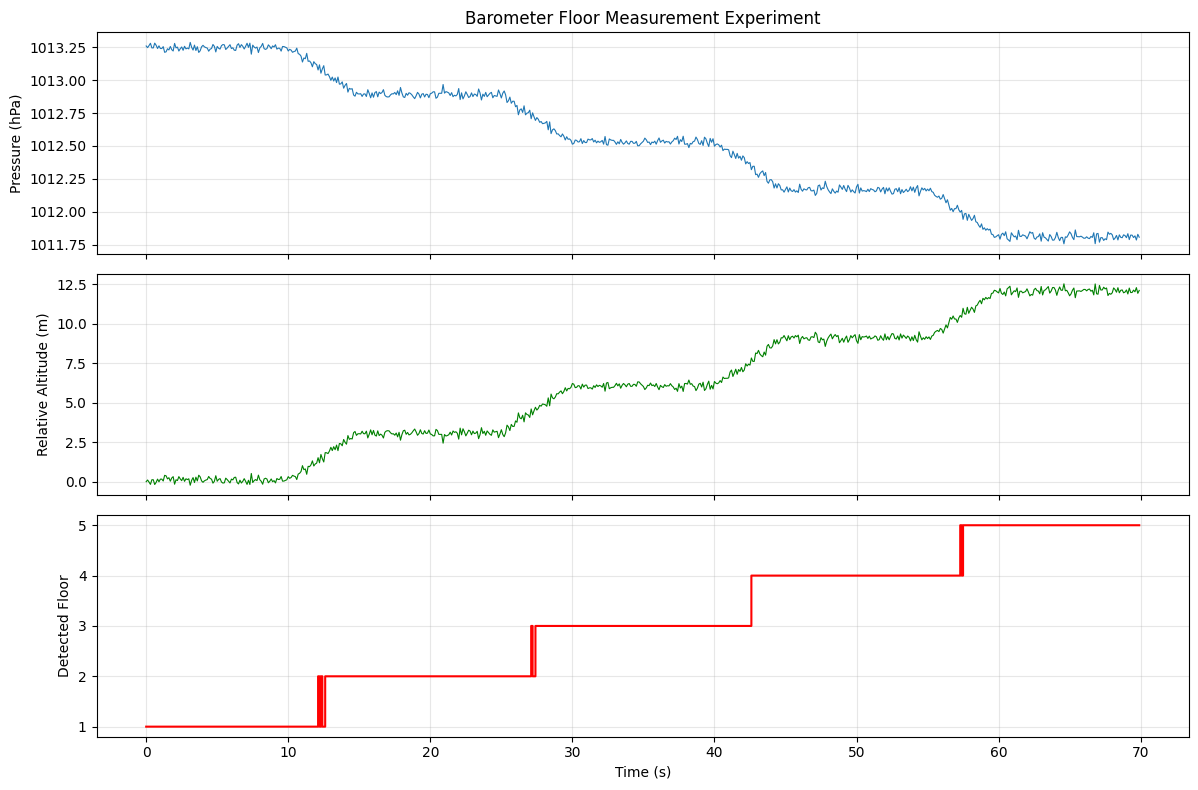

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def pressure_to_altitude(p, p0=1013.25):
    return 44330 * (1 - (p / p0) ** 0.1903)

# Simulate elevator ride from 1st to 5th floor, stopping for 10 seconds per floor
np.random.seed(42)
fs = 10  # 10 Hz
base_p = 1013.25
floor_dp = 0.36  # Pressure difference per floor in hPa

segments = []
for floor in range(5):
    # Stay phase (10 seconds)
    n_stay = fs * 10
    p_stay = base_p - floor * floor_dp + np.random.normal(0, 0.02, n_stay)
    segments.append(p_stay)

    if floor < 4:
        # Rise phase (5 seconds)
        n_rise = fs * 5
        p_rise = np.linspace(base_p - floor * floor_dp,
                             base_p - (floor+1) * floor_dp, n_rise)
        p_rise += np.random.normal(0, 0.02, n_rise)
        segments.append(p_rise)

pressure = np.concatenate(segments)
t = np.arange(len(pressure)) / fs

df = pd.DataFrame({'pressure': pressure})
df['altitude'] = df['pressure'].apply(pressure_to_altitude)
df['relative_alt'] = df['altitude'] - df['altitude'].iloc[0]
df['floor'] = (df['relative_alt'] / 3.0).round().astype(int) + 1

print(f"Starting pressure: {df['pressure'].iloc[0]:.2f} hPa")
print(f"Ending pressure: {df['pressure'].iloc[-1]:.2f} hPa")
print(f"Pressure change: {df['pressure'].iloc[-1] - df['pressure'].iloc[0]:.2f} hPa")
print(f"Altitude change: {df['relative_alt'].iloc[-1]:.1f} m")
print(f"Estimated floor change: {df['floor'].iloc[-1] - 1} floors")

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, df['pressure'], linewidth=0.8)
axes[0].set_ylabel('Pressure (hPa)')
axes[0].set_title('Barometer Floor Measurement Experiment')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, df['relative_alt'], linewidth=0.8, color='green')
axes[1].set_ylabel('Relative Altitude (m)')
axes[1].grid(True, alpha=0.3)

axes[2].step(t, df['floor'], where='post', linewidth=1.5, color='red')
axes[2].set_ylabel('Detected Floor')
axes[2].set_xlabel('Time (s)')
axes[2].set_yticks(range(1, 6))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 实验四: 手势识别 (KNN)

利用加速度计和陀螺仪数据，提取时域特征，用 KNN 分类器识别简单手势。

5-fold cross-validation accuracy: 100.00% ± 0.00%
Individual fold accuracies: ['100.00%', '100.00%', '100.00%', '100.00%', '100.00%']


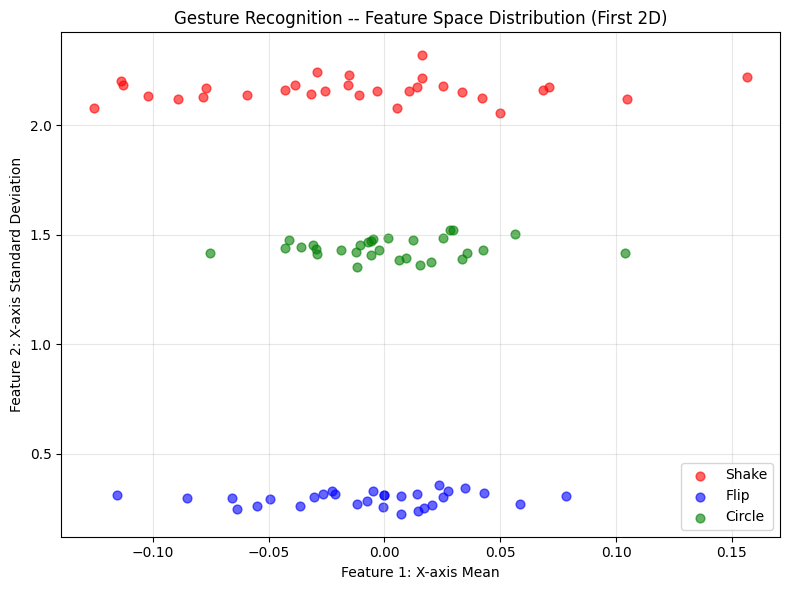

In [45]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

def extract_features(segment_data):
    """Extracts features from a sensor data segment"""
    features = []
    for col in segment_data.T:  # Each axis
        features.extend([
            col.mean(),
            col.std(),
            col.max() - col.min(),
            np.sqrt(np.mean(col**2)),  # RMS
            (np.diff(np.sign(col - col.mean())) != 0).sum(),  # Zero-crossing rate
        ])
    return features

# Generate simulated gesture data
np.random.seed(42)
n_samples_per_class = 30
window_size = 50  # 1 second @ 50Hz

X_all, y_all = [], []
gesture_names = ['Shake', 'Flip', 'Circle']

for gi, gesture in enumerate(gesture_names):
    for _ in range(n_samples_per_class):
        t = np.arange(window_size) / 50.0
        if gi == 0:  # Shake: high frequency, large amplitude
            data = np.column_stack([
                3 * np.sin(2*np.pi*5*t) + np.random.normal(0, 0.5, window_size),
                np.random.normal(0, 0.5, window_size),
                9.8 + np.random.normal(0, 0.3, window_size),
            ])
        elif gi == 1:  # Flip: large Z-axis change
            data = np.column_stack([
                np.random.normal(0, 0.3, window_size),
                np.random.normal(0, 0.3, window_size),
                9.8 * np.cos(np.pi * t) + np.random.normal(0, 0.3, window_size),
            ])
        else:  # Circle: sinusoidal with phase difference on X/Y axes
            data = np.column_stack([
                2 * np.sin(2*np.pi*2*t) + np.random.normal(0, 0.3, window_size),
                2 * np.cos(2*np.pi*2*t) + np.random.normal(0, 0.3, window_size),
                9.8 + np.random.normal(0, 0.2, window_size),
            ])

        features = extract_features(data)
        X_all.append(features)
        y_all.append(gi)

X_train = np.array(X_all)
y_train = np.array(y_all)

# KNN Classification
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X_train, y_train, cv=5)
print(f"5-fold cross-validation accuracy: {scores.mean():.2%} ± {scores.std():.2%}")
print(f"Individual fold accuracies: {[f'{s:.2%}' for s in scores]}")

# Visualize feature distribution (first two dimensions)
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
for gi, name in enumerate(gesture_names):
    mask = y_train == gi
    plt.scatter(X_train[mask, 0], X_train[mask, 1],
                c=colors[gi], label=name, alpha=0.6, s=40)

plt.xlabel('Feature 1: X-axis Mean')
plt.ylabel('Feature 2: X-axis Standard Deviation')
plt.title('Gesture Recognition -- Feature Space Distribution (First 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. SensorLog 数据分析

使用 SensorLog / Sensor Logger 导出的 CSV 数据进行加载和可视化。

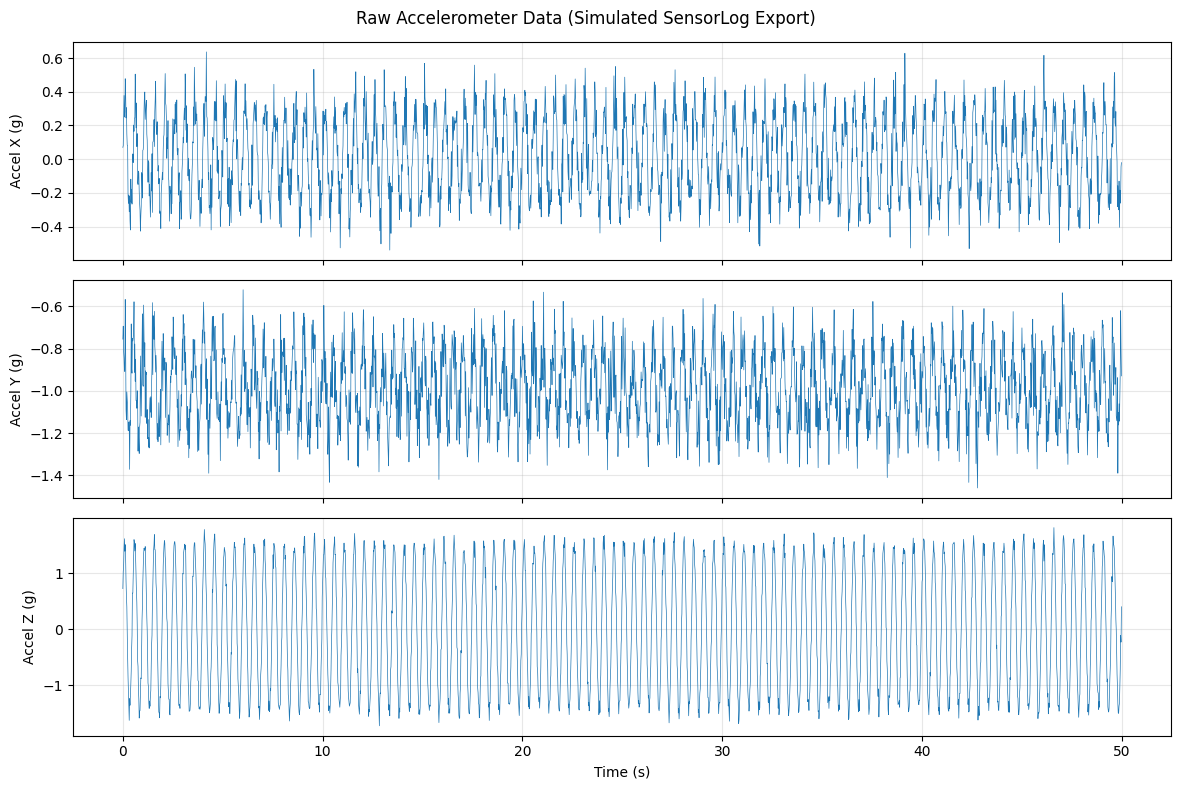


Data Statistics:
  X-axis: Mean=0.0234, Std=0.2350, Range=[-0.540, 0.636]
  Y-axis: Mean=-0.9823, Std=0.1736, Range=[-1.459, -0.521]
  Z-axis: Mean=0.0471, Std=1.0668, Range=[-1.731, 1.818]


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate simulated SensorLog CSV data
np.random.seed(42)
n = 2500  # 50 seconds @ 50Hz
t = np.arange(n) / 50.0

timestamps = pd.date_range('2026-03-27 10:00:00', periods=n, freq='20ms')

df = pd.DataFrame({
    'loggingTime': timestamps,
    'accelerometerAccelerationX': 0.02 + np.random.normal(0, 0.1, n) + 0.3 * np.sin(2*np.pi*2*t),
    'accelerometerAccelerationY': -0.98 + np.random.normal(0, 0.1, n) + 0.2 * np.sin(2*np.pi*2*t + 1),
    'accelerometerAccelerationZ': 0.05 + np.random.normal(0, 0.1, n) + 1.5 * np.sin(2*np.pi*2*t + 0.5),
})

# If you have an actual CSV file, use the following code to load it:
# df = pd.read_csv('sensorlog_data.csv')
# df['loggingTime'] = pd.to_datetime(df['loggingTime'])

df['elapsed'] = (df['loggingTime'] - df['loggingTime'].iloc[0]).dt.total_seconds()

# Plot accelerometer data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, axis in enumerate(['X', 'Y', 'Z']):
    col = f'accelerometerAcceleration{axis}'
    if col in df.columns:
        axes[i].plot(df['elapsed'], df[col], linewidth=0.5)
        axes[i].set_ylabel(f'Accel {axis} (g)')
        axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel('Time (s)')
fig.suptitle('Raw Accelerometer Data (Simulated SensorLog Export)')
plt.tight_layout()
plt.show()

# Basic statistics
print("\nData Statistics:")
for axis in ['X', 'Y', 'Z']:
    col = f'accelerometerAcceleration{axis}'
    print(f"  {axis}-axis: Mean={df[col].mean():.4f}, Std={df[col].std():.4f}, "
          f"Range=[{df[col].min():.3f}, {df[col].max():.3f}]")

---
## 5. 数据上云服务端 (参考代码)

> ⚠️ 以下代码为 **服务端程序**，需要在本地或云服务器上运行，不适合在 Colab 中直接执行。请复制到本地环境使用。

### 5.1 Flask 极简接收服务

接收 Sensor Logger 通过 HTTP POST 推送的 JSON 数据，存储为 CSV。

```python
from flask import Flask, request, jsonify
import json, csv, os

app = Flask(__name__)
os.makedirs("data", exist_ok=True)

@app.route("/data", methods=["POST"])
def receive():
    data = request.get_json()
    sid = data.get("sessionId", "unknown")
    did = data.get("deviceId", "unknown")

    filepath = f"data/{sid}.csv"
    is_new = not os.path.exists(filepath)

    with open(filepath, "a", newline="") as f:
        w = csv.writer(f)
        if is_new:
            w.writerow(["time_ns", "device", "sensor", "x", "y", "z", "extra"])
        for item in data.get("payload", []):
            v = item.get("values", {})
            w.writerow([
                item["time"], did, item["name"],
                v.get("x", v.get("latitude", v.get("pressure", ""))),
                v.get("y", v.get("longitude", v.get("relativeAltitude", ""))),
                v.get("z", v.get("altitude", "")),
                json.dumps({k: v2 for k, v2 in v.items()
                           if k not in ("x","y","z")}, ensure_ascii=False) or ""
            ])
    return jsonify(status="ok"), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)
```

**使用方法:**
1. `pip install flask`
2. `python server.py`
3. Sensor Logger Push URL 填: `http://你的IP:8000/data`

### 5.2 Plotly Dash 实时可视化仪表盘

边采集边查看加速度波形。

```python
import dash
from dash.dependencies import Output, Input
from dash import dcc, html
from datetime import datetime
import json, plotly.graph_objs as go
from collections import deque
from flask import Flask, request

server = Flask(__name__)
app = dash.Dash(__name__, server=server)

MAX_POINTS = 1000
time_q = deque(maxlen=MAX_POINTS)
ax, ay, az = deque(maxlen=MAX_POINTS), deque(maxlen=MAX_POINTS), deque(maxlen=MAX_POINTS)

app.layout = html.Div([
    html.H2("Sensor Logger 实时加速度"),
    dcc.Graph(id="live"),
    dcc.Interval(id="tick", interval=200),
])

@app.callback(Output("live", "figure"), Input("tick", "n_intervals"))
def update(_):
    traces = [go.Scatter(x=list(time_q), y=list(d), name=n)
              for d, n in zip([ax, ay, az], ["X", "Y", "Z"])]
    layout = go.Layout(xaxis={"type": "date"}, yaxis={"title": "加速度 (m/s²)"})
    if time_q:
        layout["xaxis"]["range"] = [min(time_q), max(time_q)]
    return {"data": traces, "layout": layout}

@server.route("/data", methods=["POST"])
def data():
    for d in json.loads(request.data).get("payload", []):
        if d.get("name") == "accelerometer":
            ts = datetime.fromtimestamp(d["time"] / 1e9)
            if not time_q or ts > time_q[-1]:
                time_q.append(ts)
                ax.append(d["values"]["x"])
                ay.append(d["values"]["y"])
                az.append(d["values"]["z"])
    return "ok"

if __name__ == "__main__":
    app.run_server(port=8000, host="0.0.0.0")
```

**使用方法:**
1. `pip install dash plotly flask`
2. `python dashboard.py`
3. 浏览器打开 `http://服务器IP:8000`、App Push URL 填同一地址的 `/data`

### 5.3 MQTT 订阅与存储

订阅所有设备的 MQTT 消息，写入 SQLite 数据库。

```python
import paho.mqtt.client as mqtt
import json, sqlite3
from datetime import datetime

# 初始化数据库
db = sqlite3.connect("sensor_cloud.db", check_same_thread=False)
db.execute("""CREATE TABLE IF NOT EXISTS readings (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    recv_time TEXT, device TEXT, session TEXT,
    sensor TEXT, time_ns INTEGER,
    val_json TEXT
)""")

def on_connect(client, userdata, flags, rc):
    print(f"已连接 Broker, rc={rc}")
    client.subscribe("sensor/#")  # 订阅所有设备

def on_message(client, userdata, msg):
    data = json.loads(msg.payload.decode())
    device = data.get("deviceId", "")
    session = data.get("sessionId", "")
    now = datetime.utcnow().isoformat()

    for item in data.get("payload", []):
        db.execute(
            "INSERT INTO readings (recv_time,device,session,sensor,time_ns,val_json) VALUES (?,?,?,?,?,?)",
            [now, device, session, item["name"], item["time"], json.dumps(item["values"])]
        )
    db.commit()

client = mqtt.Client(transport="websockets")
client.tls_set()  # wss 需要 TLS
client.on_connect = on_connect
client.on_message = on_message
client.connect("broker.emqx.io", 8084)
print("开始监听 MQTT 消息...")
client.loop_forever()
```

**使用方法:**
1. `pip install paho-mqtt`
2. `python mqtt_subscriber.py`
3. Sensor Logger MQTT Broker 填: `wss://broker.emqx.io:8084/mqtt`, Topic: `sensor/${deviceId}`

### 5.4 批量文件上传

导出的 CSV 文件批量上传到服务器。

```python
import requests, glob, os

API = "https://your-server.com/api/upload"

for fp in glob.glob("exports/*.csv"):
    with open(fp, "rb") as f:
        r = requests.post(API, files={"file": (os.path.basename(fp), f)})
        print(f"{fp}: {r.status_code}")
```

**对应的服务端接收代码:**

```python
from flask import Flask, request
import pandas as pd, os

app = Flask(__name__)

@app.route("/api/upload", methods=["POST"])
def upload():
    f = request.files["file"]
    save_path = f"uploads/{f.filename}"
    f.save(save_path)

    # 读入 pandas 做预处理
    df = pd.read_csv(save_path)
    print(f"收到 {f.filename}: {len(df)} 行, 列: {list(df.columns)}")

    return {"status": "ok", "rows": len(df)}, 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
```

---
## 附录: JSON Payload 格式参考

Sensor Logger HTTP POST / MQTT 推送的 JSON 结构:

```json
{
  "messageId": 42,
  "sessionId": "a1b2c3d4-e5f6-7890",
  "deviceId": "iPhone-XYZ",
  "payload": [
    {
      "name": "accelerometer",
      "time": 1711526400000000000,
      "values": { "x": 0.023, "y": -0.981, "z": 0.045 }
    },
    {
      "name": "gyroscope",
      "time": 1711526400000000000,
      "values": { "x": 0.001, "y": -0.003, "z": 0.007 }
    }
  ]
}
```

时间戳转换: `pd.to_datetime(1711526400000000000, unit='ns')` → `2024-03-27 08:00:00 UTC`

---

**课程网站:** [https://zebedee2021.github.io/Mobile-Sensor-2026/](https://zebedee2021.github.io/Mobile-Sensor-2026/)  
**GitHub 仓库:** [https://github.com/Zebedee2021/Mobile-Sensor-2026](https://github.com/Zebedee2021/Mobile-Sensor-2026)  
**作者:** Zhiguo Zhou | 2026